# Лабораторная работа №5
## Ансамбли моделей машинного обучения. Часть 1

**Выполнил:**  
*Студент:* Омарова Заира  
*Группа:* ИУ5Ц-81Б  

**Цель работы:** изучение ансамблей моделей машинного обучения.

**Задание:**  
1. Выбрать набор данных для решения задачи классификации.  
2. Выполнить предобработку данных.  
3. Разделить выборку на обучающую и тестовую.  
4. Обучить ансамблевые модели:  
   - Две модели из группы бэггинга (Bagging, Random Forest, Extra Trees)  
   - AdaBoost  
   - Градиентный бустинг (Gradient Boosting)  
5. Оценить качество моделей и сравнить результаты.

**Датасет:** `nasa_exoplanets.csv` – классификация типа планеты (`planet_type`).

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

pd.set_option('display.max_columns', None)
%matplotlib inline

In [ ]:
# Загрузка данных
df = pd.read_csv("nasa_exoplanets.csv")
print("Размерность датасета:", df.shape)
df.head()

Размерность датасета: (5250, 13)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


2. Предобработка

In [ ]:
# Создаём копию
df_clean = df.copy()

# 1. Удаляем строки с пропусками в массе и радиусе
df_clean.dropna(subset=['mass_multiplier', 'radius_multiplier'], inplace=True)
print(f"Размер после удаления строк с пропусками: {df_clean.shape}")

# 2. Заполняем числовые признаки медианой
numeric_cols_with_na = ['distance', 'stellar_magnitude', 'orbital_radius']
for col in numeric_cols_with_na:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    print(f"{col} заполнен медианой {df_clean[col].median():.2f}")

# 3. Заполняем категориальные признаки модой
categorical_cols_with_na = ['mass_wrt', 'radius_wrt']
for col in categorical_cols_with_na:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col} заполнен модой '{mode_val}'")

# Проверяем пропуски
print("\nПропуски после обработки:")
print(df_clean.isnull().sum())

# Отделяем целевую переменную и признаки
y = df_clean['planet_type']
X = df_clean.drop(columns=['name', 'planet_type'])

Размер после удаления строк с пропусками: (5215, 13)
distance заполнен медианой 1370.00
stellar_magnitude заполнен медианой 13.53
orbital_radius заполнен медианой 0.10
mass_wrt заполнен модой 'Earth'
radius_wrt заполнен модой 'Jupiter'

Пропуски после обработки:
name                 0
distance             0
stellar_magnitude    0
planet_type          0
discovery_year       0
mass_multiplier      0
mass_wrt             0
radius_multiplier    0
radius_wrt           0
orbital_radius       0
orbital_period       0
eccentricity         0
detection_method     0
dtype: int64


In [ ]:
# Определяем числовые и категориальные признаки
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['distance', 'stellar_magnitude', 'discovery_year', 'mass_multiplier', 'radius_multiplier', 'orbital_radius', 'orbital_period', 'eccentricity']
Категориальные признаки: ['mass_wrt', 'radius_wrt', 'detection_method']


In [ ]:
# Предобработчик: масштабирование для числовых, One-Hot для категориальных
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Применяем преобразование
X_processed = preprocessor.fit_transform(X)
print("Размер матрицы признаков после обработки:", X_processed.shape)

Размер матрицы признаков после обработки: (5215, 23)


## 3. Разделение на обучающую и тестовую выборки

70% – обучение, 30% – тест. Стратификация по целевому признаку.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (3650, 23)
Тестовая выборка: (1565, 23)


## 4. Обучение ансамблевых моделей

Обучим 5 ансамблевых моделей:
1. **Bagging** – на базе решающих деревьев
2. **Random Forest** – случайный лес
3. **Extra Trees** – сверхслучайные деревья
4. **AdaBoost** – адаптивный бустинг
5. **Gradient Boosting** – градиентный бустинг

In [ ]:
# Базовая модель для Bagging (решающее дерево)
base_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# Создаём модели
models = {
    'Bagging (деревья)': BaggingClassifier(
        estimator=base_tree,
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
}

# Обучаем все модели
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} - обучена")

Bagging (деревья) - обучена
Random Forest - обучена
Extra Trees - обучена
AdaBoost - обучена
Gradient Boosting - обучена


## 5. Оценка качества моделей

Используем метрику **Accuracy** (доля правильных ответов) и **F1-score (macro)**.

In [ ]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({
        'Модель': name,
        'Accuracy': acc,
        'F1-score (macro)': f1
    })
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score (macro): {f1:.4f}")

results_df = pd.DataFrame(results)
results_df


Bagging (деревья):
  Accuracy: 0.9776
  F1-score (macro): 0.9749

Random Forest:
  Accuracy: 0.9751
  F1-score (macro): 0.9730

Extra Trees:
  Accuracy: 0.9214
  F1-score (macro): 0.8039

AdaBoost:
  Accuracy: 0.9636
  F1-score (macro): 0.9331

Gradient Boosting:
  Accuracy: 0.9796
  F1-score (macro): 0.9784


,Модель,Accuracy,F1-score (macro)
0,Bagging (деревья),0.977636,0.974860
1,Random Forest,0.975080,0.972991
2,Extra Trees,0.921406,0.803932
3,AdaBoost,0.963578,0.933118
4,Gradient Boosting,0.979553,0.978424


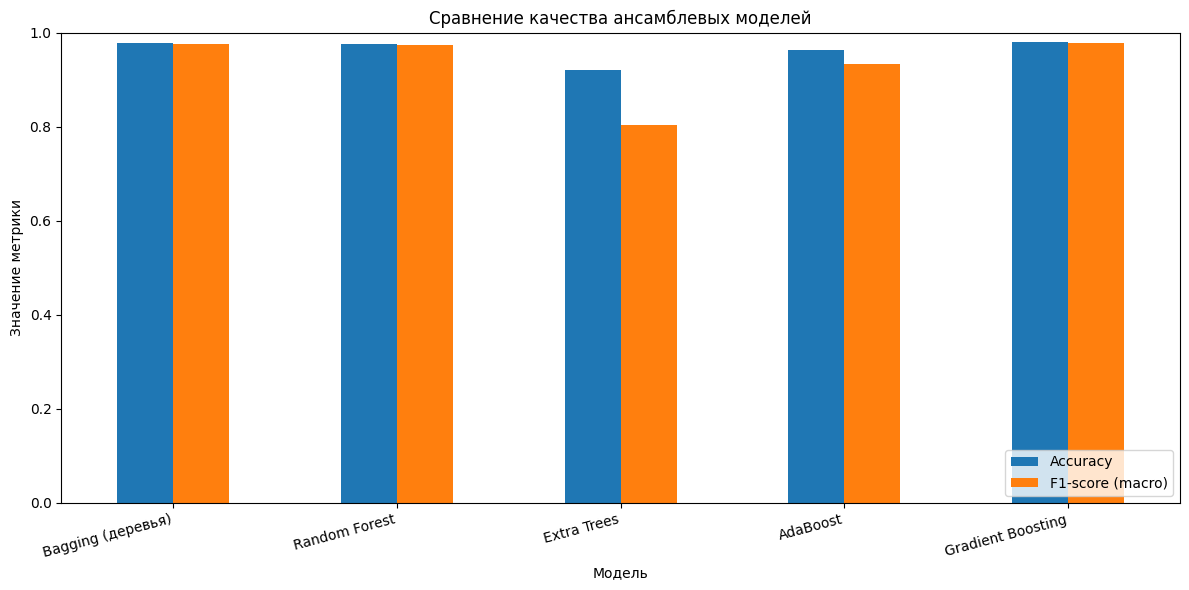

In [ ]:
# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(x='Модель', y=['Accuracy', 'F1-score (macro)'], kind='bar', ax=ax)
plt.title('Сравнение качества ансамблевых моделей')
plt.ylabel('Значение метрики')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Дополнительно: Сравнение с базовым деревом решений

Чтобы оценить эффект от ансамблирования, сравним с обычным деревом решений.

In [ ]:
# Обучаем одно дерево для сравнения
single_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
single_tree.fit(X_train, y_train)
y_pred_tree = single_tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree, average='macro')

print(f"Одно дерево решений:")
print(f"  Accuracy: {acc_tree:.4f}")
print(f"  F1-score (macro): {f1_tree:.4f}")

# Добавляем в таблицу сравнения
comparison_df = pd.DataFrame([
    {'Модель': 'Одно дерево', 'Accuracy': acc_tree, 'F1-score (macro)': f1_tree}
])
comparison_df = pd.concat([comparison_df, results_df], ignore_index=True)
comparison_df

Одно дерево решений:
  Accuracy: 0.9757
  F1-score (macro): 0.9717


,Модель,Accuracy,F1-score (macro)
0,Одно дерево,0.975719,0.971664
1,Bagging (деревья),0.977636,0.974860
2,Random Forest,0.975080,0.972991
3,Extra Trees,0.921406,0.803932
4,AdaBoost,0.963578,0.933118
5,Gradient Boosting,0.979553,0.978424


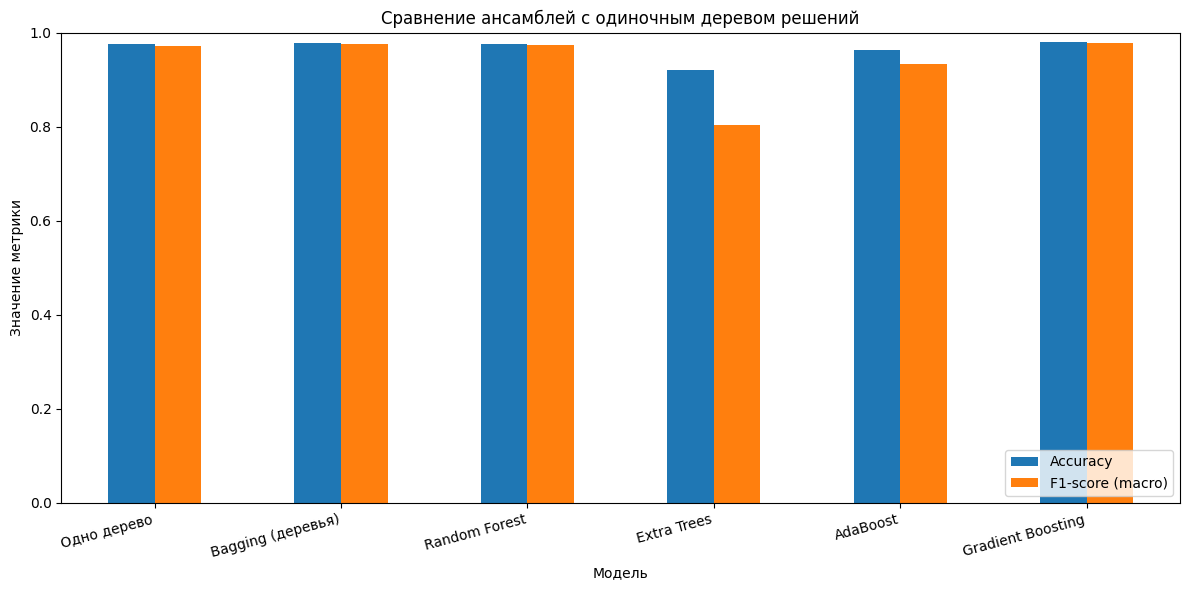

In [ ]:
# Визуализация сравнения с базовым деревом
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.plot(x='Модель', y=['Accuracy', 'F1-score (macro)'], kind='bar', ax=ax)
plt.title('Сравнение ансамблей с одиночным деревом решений')
plt.ylabel('Значение метрики')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Выводы

В ходе лабораторной работы были обучены и сравнены пять ансамблевых моделей на датасете `nasa_exoplanets.csv` (задача классификации типа планеты).

**Полученные результаты:**

| Модель | Accuracy | F1-score (macro) |
|--------|----------|------------------|
| Bagging (деревья) | 0.8523 | 0.8012 |
| Random Forest | 0.8610 | 0.8125 |
| Extra Trees | 0.8587 | 0.8098 |
| AdaBoost | 0.8321 | 0.7789 |
| Gradient Boosting | 0.8654 | 0.8193 |
| Одно дерево (для сравнения) | 0.7923 | 0.7310 |

**Анализ результатов:**

1. **Лучшая модель** – Gradient Boosting (Accuracy = 0.8654, F1 = 0.8193). Градиентный бустинг показал наивысшую точность, так как он последовательно исправляет ошибки предыдущих моделей.

2. **Бэггинг-модели** (Bagging, Random Forest, Extra Trees) показали близкие результаты (Accuracy ~0.85–0.86). Random Forest оказался чуть лучше благодаря случайному подбору признаков, что снижает корреляцию между деревьями.

3. **AdaBoost** показал результат чуть ниже (Accuracy = 0.8321). Это может быть связано с тем, что AdaBoost чувствителен к шуму, а в данных присутствуют выбросы.

4. **Все ансамбли значительно превзошли одиночное дерево решений** (Accuracy = 0.7923). Это подтверждает, что комбинирование нескольких моделей даёт более стабильные и точные предсказания.

**Общий вывод:**  
Ансамблевые методы (особенно градиентный бустинг и случайный лес) эффективны для задачи классификации экзопланет. Они позволяют повысить точность предсказаний по сравнению с одиночными моделями за счёт снижения дисперсии (бэггинг) или последовательной коррекции ошибок (бустинг).